# Random Walker in Parameter Space

This notebook performs a random walk in parameter space and tracks the evolution of eigenvalues and eigenvectors.


In [39]:
# Settings for random walk
n_steps = 400              # number of random walk steps
step_variance = 0.001      # variance of Gaussian step (mean=0)
sloppy_threshold = 1e-3    # threshold for identifying sloppy eigenvectors
eigenvector_match_threshold = 0.8  # minimum inner product to consider eigenvectors matched
tol_positive_eig = 1e-30   # threshold to consider eigenvalue as positive


In [40]:
# Sloppiness analysis for the Tyson-like 6-state ODE example
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigh, svd
import copy

# === Base parameters (user provided) ===
p = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# We'll analyze these parameters
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
]
pvec = np.array([p[name] for name in param_names])
p_index = {name:i for i,name in enumerate(param_names)}
P = len(param_names)

# === model right-hand side and helper functions ===
CT = p["CT"]

def F_M(M, p):
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    return p["k4"] * 2.0 * (M / p["CT"]) * (1.0 / p["CT"])

def f_rhs(t, x, p):
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def jacobian_fx(x, p):
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    dF = dF_dM(M, p)
    J = np.zeros((6,6))
    J[0,0] = -p["k8_minusP"]
    J[0,1] = p["k9"]
    J[0,3] = p["k6"]
    J[1,0] = p["k8_minusP"]
    J[1,1] = -k3*Y - p["k9"]
    J[1,4] = -k3*CP
    J[2,1] = k3*Y
    J[2,2] = -F_M(M, p)
    J[2,3] = -pM * dF + p["k5_minusP"]
    J[2,4] = k3*CP
    J[3,2] = F_M(M, p)
    J[3,3] = pM * dF - p["k5_minusP"] - p["k6"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    J[4,1] = -k3 * Y
    J[4,4] = -p["k2"] - k3 * CP
    J[5,3] = p["k6"]
    J[5,5] = -p["k7"]
    return J

def df_dparam(x, p):
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    dfdh = np.zeros((6, P))
    for j,name in enumerate(param_names):
        if name == "k1_aa_over_CT":
            df = np.zeros(6); df[4] = p['CT']
            dfdh[:,j] = df
        elif name == "k3_CT":
            coeff = 1.0 / p["CT"]
            df = np.zeros(6)
            df[1] = -coeff * CP * Y
            df[2] =  coeff * CP * Y
            df[4] = -coeff * CP * Y
            dfdh[:,j] = df
        elif name == "k4":
            df = np.zeros(6)
            dFdk4 = (M / p["CT"])**2
            df[2] = -pM * dFdk4
            df[3] =  pM * dFdk4
            dfdh[:,j] = df
        elif name == "k4prime":
            df = np.zeros(6)
            df[2] = -pM
            df[3] =  pM
            dfdh[:,j] = df
        elif name == "k6":
            df = np.zeros(6)
            df[0] = M
            df[3] = -M
            df[5] = M
            dfdh[:,j] = df
        elif name == "k7":
            df = np.zeros(6)
            df[5] = -YP
            dfdh[:,j] = df
        else:
            raise KeyError(name)
    return dfdh

# === Sensitivity ODE: augmented system ===
def augmented_rhs(t, z, p_local):
    x = z[:6]
    S_flat = z[6:]
    S = S_flat.reshape((6, P), order='F')
    xdot = f_rhs(t, x, p_local)
    A = jacobian_fx(x, p_local)
    df_dh = df_dparam(x, p_local)
    df_dlogh = np.zeros_like(df_dh)
    for j,name in enumerate(param_names):
        df_dlogh[:, j] = p_local[name] * df_dh[:, j]
    Sdot = A.dot(S) + df_dlogh
    return np.concatenate([xdot, Sdot.ravel(order='F')])

# === Function to compute Hessian/Fisher Information Matrix ===
def compute_H_for_params(p_local):
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    S0 = np.zeros((6, P))
    z0 = np.concatenate([y0, S0.ravel(order='F')])
    
    t_span = (0.0, 100.0)
    t_eval = np.linspace(t_span[0], t_span[1], 1001)
    
    def augmented_rhs_local(t, z):
        return augmented_rhs(t, z, p_local)
    
    sol = solve_ivp(augmented_rhs_local, t_span, z0, method='BDF',
                    t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Augmented integration failed: " + sol.message)
    
    m = sol.t.size
    S_flat = sol.y[6:, :]
    S_time = np.zeros((6, P, m))
    for i in range(m):
        S_time[:, :, i] = S_flat[:, i].reshape((6, P), order='F')
    
    J_time = S_time.copy()
    
    Ns = 6
    Nc = 1
    Tc = t_span[1] - t_span[0]
    sigma = 1.0
    W_diag = np.ones(Ns) * (1.0 / (Nc * Ns * Tc * sigma**2))
    W = np.diag(W_diag)
    
    dt = np.diff(sol.t)
    q = np.zeros(m)
    if m >= 2:
        q[0] = dt[0] / 2.0
        q[-1] = dt[-1] / 2.0
        if m > 2:
            q[1:-1] = 0.5 * (dt[:-1] + dt[1:])
    
    H = np.zeros((P, P))
    for i in range(m):
        J_i = J_time[:, :, i]
        A_i = J_i.T.dot(W).dot(J_i)
        H += q[i] * A_i
    
    eigvals, eigvecs = eigh(H)
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]
    
    return {'H': H, 'eigvals': eigvals, 'eigvecs': eigvecs}

# === Simulation and observation functions ===
def simulate_at_params(p_local, t_eval):
    """Simulate the ODE system with given parameters"""
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y  # t, (6 x m)

def compute_obs(X, CT_local):
    """Compute observables from state vector X: YT/CT and M/CT"""
    C2, CP, pM, M, Y, YP = X
    YT = Y + YP + pM + M
    return YT / CT_local, M / CT_local

print("✓ Setup complete")


✓ Setup complete


In [41]:
# === Random Walk in Parameter Space ===

print("="*60)
print("Starting Random Walk")
print("="*60)
print(f"Steps: {n_steps}")
print(f"Step variance: {step_variance}")
print(f"Eigenvector match threshold: {eigenvector_match_threshold}")
print("="*60)

# Storage for results
param_history = []
logparam_history = []
eigvals_history = []
eigvecs_history = []
match_quality_history = []  # Track eigenvector matching quality

# Start at initial parameters
p_current = copy.deepcopy(p)
param_history.append(copy.deepcopy(p_current))
logparam_history.append(np.log([p_current[name] for name in param_names]))

# Compute initial Hessian
print("\nComputing initial Hessian...")
res = compute_H_for_params(p_current)
eigvals_current = res['eigvals']
eigvecs_current = res['eigvecs']
eigvals_history.append(eigvals_current.copy())
eigvecs_history.append(eigvecs_current.copy())
match_quality_history.append(None)  # No previous step to match

print(f"Initial eigenvalues: {eigvals_current}")

# Random walk loop
for step in range(1, n_steps + 1):
    print(f"\n--- Step {step}/{n_steps} ---")
    
    # Take random step in log-parameter space
    # Step is Gaussian with mean=0, variance=step_variance
    random_step = np.random.normal(0, np.sqrt(step_variance), size=P)
    
    # Update parameters in log space
    log_params_current = np.log([p_current[name] for name in param_names])
    log_params_new = log_params_current + random_step
    
    # Convert back to linear space
    p_new = copy.deepcopy(p_current)
    for j, name in enumerate(param_names):
        p_new[name] = np.exp(log_params_new[j])
    
    # Compute Hessian at new point
    print(f"  Computing Hessian at step {step}...")
    res = compute_H_for_params(p_new)
    eigvals_new = res['eigvals']
    eigvecs_new = res['eigvecs']
    
    # Match eigenvectors to previous step
    # Use inner products to find best matches
    eigvecs_prev = eigvecs_history[-1]
    match_quality = np.zeros(P)
    matched_indices = np.zeros(P, dtype=int)
    used_indices = set()
    
    # For each eigenvector in previous step, find best match in new step
    for i in range(P):
        best_match = -1
        best_inner_product = -1
        
        for j in range(P):
            if j in used_indices:
                continue
            # Compute absolute inner product (eigenvectors can be flipped)
            inner_prod = abs(np.dot(eigvecs_prev[:, i], eigvecs_new[:, j]))
            if inner_prod > best_inner_product:
                best_inner_product = inner_prod
                best_match = j
        
        if best_match >= 0:
            matched_indices[i] = best_match
            match_quality[i] = best_inner_product
            used_indices.add(best_match)
    
    # Check if matching quality is reasonable
    min_match = np.min(match_quality)
    mean_match = np.mean(match_quality)
    
    print(f"  Eigenvector matching quality: min={min_match:.4f}, mean={mean_match:.4f}")
    
    if min_match < eigenvector_match_threshold:
        print(f"  ⚠️  WARNING: Minimum match quality ({min_match:.4f}) < threshold ({eigenvector_match_threshold})")
        print(f"     Step size may be too large for reliable eigenvector tracking!")
    
    # Reorder new eigenvectors to match previous ordering
    eigvecs_matched = eigvecs_new[:, matched_indices].copy()
    eigvals_matched = eigvals_new[matched_indices].copy()
    
    # Store results
    param_history.append(copy.deepcopy(p_new))
    logparam_history.append(log_params_new.copy())
    eigvals_history.append(eigvals_matched.copy())
    eigvecs_history.append(eigvecs_matched.copy())
    match_quality_history.append(match_quality.copy())
    
    # Update for next iteration
    p_current = p_new
    
    # Progress update every 10 steps
    if step % 10 == 0:
        print(f"  Progress: {step}/{n_steps} steps completed")

print("\n" + "="*60)
print("Random walk completed!")
print("="*60)


Starting Random Walk
Steps: 400
Step variance: 0.001
Eigenvector match threshold: 0.8

Computing initial Hessian...
Initial eigenvalues: [8.18676459e+00 1.01473158e-01 3.54427789e-04 2.74331701e-04
 1.35317273e-04 7.76482530e-09]

--- Step 1/400 ---
  Computing Hessian at step 1...
  Eigenvector matching quality: min=0.9984, mean=0.9994

--- Step 2/400 ---
  Computing Hessian at step 2...
  Eigenvector matching quality: min=0.9999, mean=1.0000

--- Step 3/400 ---
  Computing Hessian at step 3...
  Eigenvector matching quality: min=0.9938, mean=0.9976

--- Step 4/400 ---
  Computing Hessian at step 4...
  Eigenvector matching quality: min=0.9863, mean=0.9952

--- Step 5/400 ---
  Computing Hessian at step 5...
  Eigenvector matching quality: min=0.9995, mean=0.9998

--- Step 6/400 ---
  Computing Hessian at step 6...
  Eigenvector matching quality: min=0.9981, mean=0.9993

--- Step 7/400 ---
  Computing Hessian at step 7...
  Eigenvector matching quality: min=0.9963, mean=0.9988

--- St

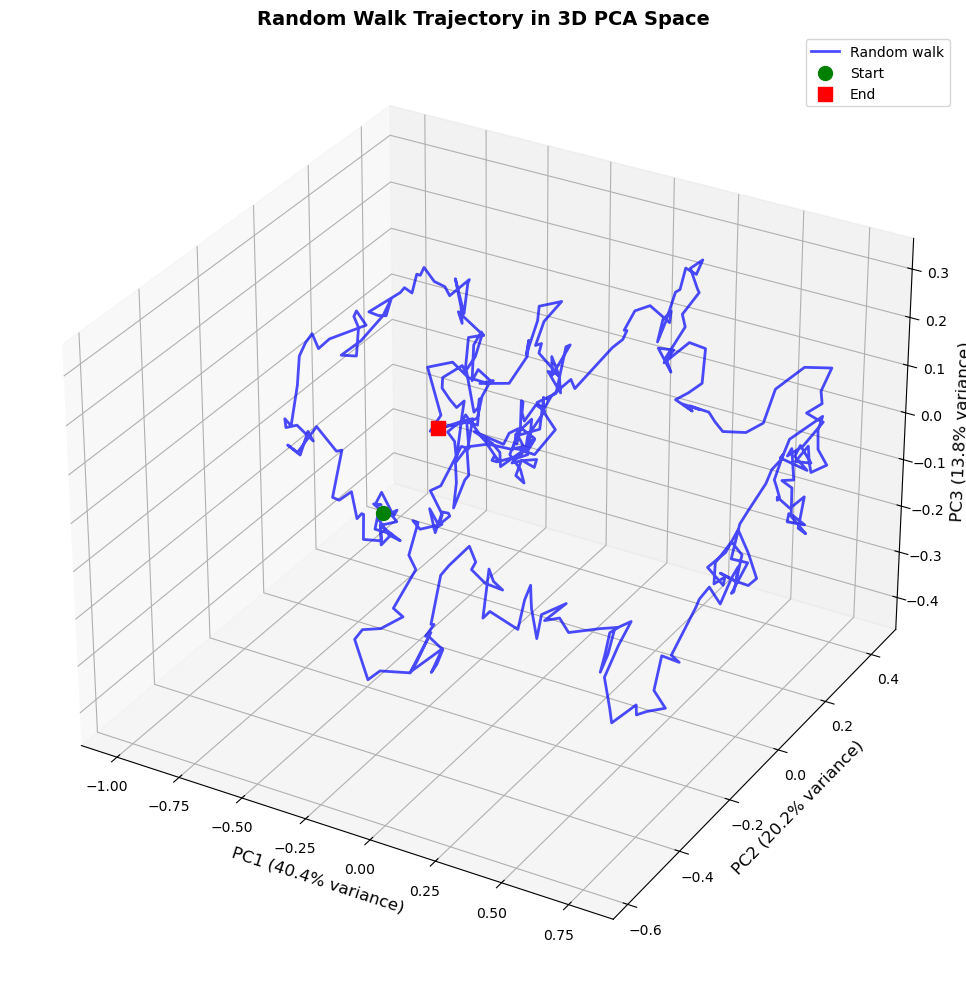

PCA variance explained by first 3 components: 74.43%


In [42]:
# === Visualization: 3D PCA Trajectory ===

logparam_mat = np.vstack(logparam_history)  # (n_steps+1) x P

# Center and compute PCA
Xc = logparam_mat - logparam_mat.mean(axis=0)
U, svals, Vt = svd(Xc, full_matrices=False)

# Project onto first 3 principal components
n_components = 3
X_pca = Xc @ Vt[:n_components, :].T

# Create 3D plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory
ax.plot(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 'b-', linewidth=2, alpha=0.7, label='Random walk')
ax.scatter(X_pca[0, 0], X_pca[0, 1], X_pca[0, 2], color='green', s=100, marker='o', label='Start', zorder=5)
ax.scatter(X_pca[-1, 0], X_pca[-1, 1], X_pca[-1, 2], color='red', s=100, marker='s', label='End', zorder=5)

ax.set_xlabel(f'PC1 ({svals[0]/svals.sum()*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({svals[1]/svals.sum()*100:.1f}% variance)', fontsize=12)
ax.set_zlabel(f'PC3 ({svals[2]/svals.sum()*100:.1f}% variance)', fontsize=12)
ax.set_title('Random Walk Trajectory in 3D PCA Space', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PCA variance explained by first 3 components: {svals[:3].sum()/svals.sum()*100:.2f}%")


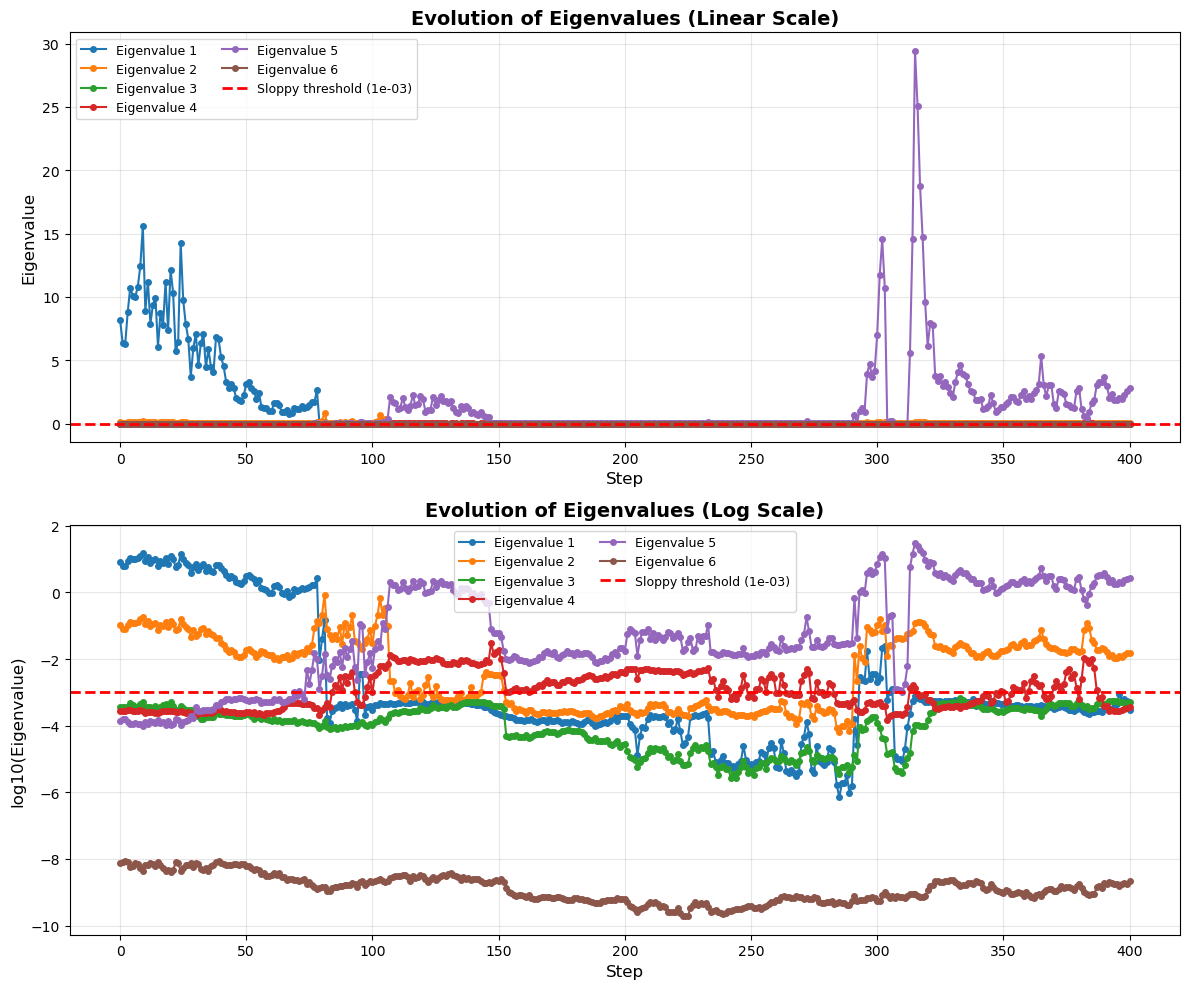

In [43]:
# === Visualization: Evolution of Eigenvalues ===

eigvals_array = np.array(eigvals_history)  # (n_steps+1) x P
steps = np.arange(len(eigvals_history))

# Plot all eigenvalues
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Linear scale
ax1 = axes[0]
for i in range(P):
    ax1.plot(steps, eigvals_array[:, i], 'o-', label=f'Eigenvalue {i+1}', markersize=4, linewidth=1.5)
ax1.axhline(sloppy_threshold, color='red', linestyle='--', linewidth=2, label=f'Sloppy threshold ({sloppy_threshold:.0e})')
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Eigenvalue', fontsize=12)
ax1.set_title('Evolution of Eigenvalues (Linear Scale)', fontsize=14, fontweight='bold')
ax1.legend(ncol=2, fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Log scale
ax2 = axes[1]
for i in range(P):
    # Only plot positive eigenvalues
    mask = eigvals_array[:, i] > 0
    if np.any(mask):
        ax2.plot(steps[mask], np.log10(eigvals_array[mask, i]), 'o-', label=f'Eigenvalue {i+1}', markersize=4, linewidth=1.5)
ax2.axhline(np.log10(sloppy_threshold), color='red', linestyle='--', linewidth=2, label=f'Sloppy threshold ({sloppy_threshold:.0e})')
ax2.set_xlabel('Step', fontsize=12)
ax2.set_ylabel('log10(Eigenvalue)', fontsize=12)
ax2.set_title('Evolution of Eigenvalues (Log Scale)', fontsize=14, fontweight='bold')
ax2.legend(ncol=2, fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Plotting observables for steps: [0, 100, 200, 300, 400]


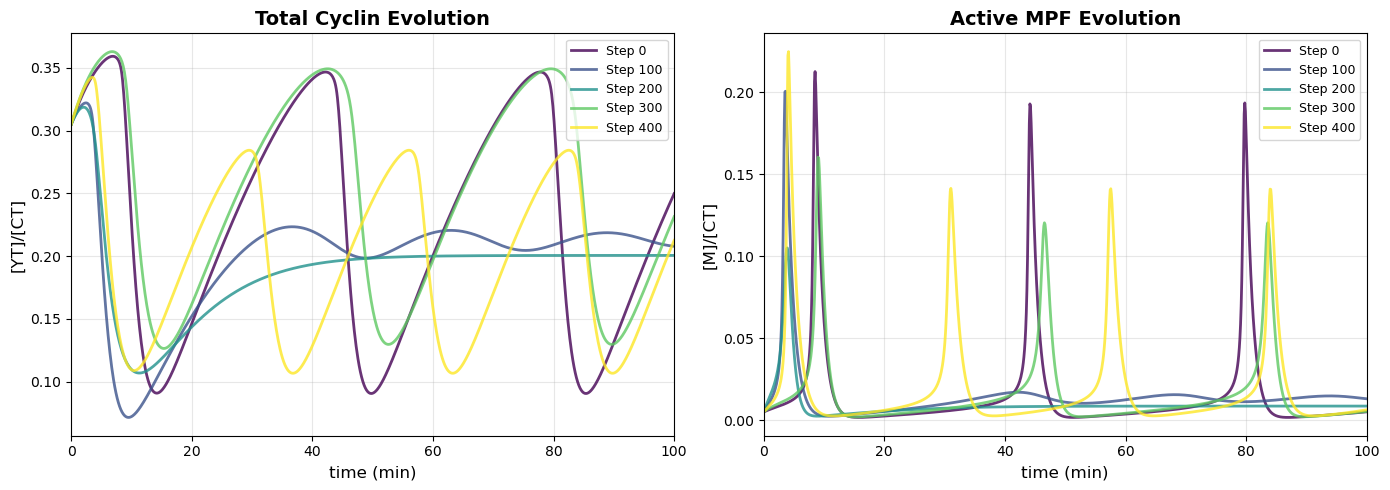


PARAMETER VALUES AT SELECTED STEPS

Step 0:
  k1_aa_over_CT  : 0.015
  k3_CT          : 200
  k4             : 180
  k4prime        : 0.018
  k6             : 1
  k7             : 0.6

Step 100:
  k1_aa_over_CT  : 0.0119599
  k3_CT          : 364.021
  k4             : 202.437
  k4prime        : 0.0314008
  k6             : 0.917638
  k7             : 0.64515

Step 200:
  k1_aa_over_CT  : 0.0113645
  k3_CT          : 561.779
  k4             : 199.826
  k4prime        : 0.0561426
  k6             : 1.33751
  k7             : 0.366454

Step 300:
  k1_aa_over_CT  : 0.0163283
  k3_CT          : 682.407
  k4             : 166.081
  k4prime        : 0.0245108
  k6             : 1.1218
  k7             : 0.407103

Step 400:
  k1_aa_over_CT  : 0.0161914
  k3_CT          : 569.348
  k4             : 204.153
  k4prime        : 0.0242036
  k6             : 0.912703
  k7             : 0.480494


In [44]:
# === Visualization: Observable Evolution (YT and M) ===

# Select steps to plot: first, three evenly spaced in middle, last
n_total = len(param_history)
indices_to_plot = [0]  # First
if n_total > 1:
    # Add three evenly spaced in middle
    if n_total > 4:
        middle_start = n_total // 4
        middle_end = 3 * n_total // 4
        middle_indices = np.linspace(middle_start, middle_end, 3, dtype=int)
        indices_to_plot.extend(middle_indices.tolist())
    # Add last
    indices_to_plot.append(n_total - 1)
    indices_to_plot = sorted(list(set(indices_to_plot)))  # Remove duplicates and sort

print(f"Plotting observables for steps: {indices_to_plot}")

# Time grid for simulation
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# Simulate and plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use colormap to color by order
colors = plt.cm.viridis(np.linspace(0, 1, len(indices_to_plot)))

for idx, step_idx in enumerate(indices_to_plot):
    p_step = param_history[step_idx]
    CT_local = p_step['CT']
    
    # Simulate
    t_sim, y_sim = simulate_at_params(p_step, t_eval)
    
    # Compute observables
    YT_rel, M_rel = compute_obs(y_sim, CT_local)
    
    # Plot
    label = f'Step {step_idx}' if step_idx in [0, n_total-1] else f'Step {step_idx}'
    axes[0].plot(t_sim, YT_rel, lw=2, label=label, color=colors[idx], alpha=0.8)
    axes[1].plot(t_sim, M_rel, lw=2, label=label, color=colors[idx], alpha=0.8)

axes[0].set_xlabel('time (min)', fontsize=12)
axes[0].set_ylabel('[YT]/[CT]', fontsize=12)
axes[0].set_title('Total Cyclin Evolution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 100)

axes[1].set_xlabel('time (min)', fontsize=12)
axes[1].set_ylabel('[M]/[CT]', fontsize=12)
axes[1].set_title('Active MPF Evolution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Print parameter values for selected steps
print("\n" + "="*60)
print("PARAMETER VALUES AT SELECTED STEPS")
print("="*60)
for step_idx in indices_to_plot:
    p_step = param_history[step_idx]
    print(f"\nStep {step_idx}:")
    for name in param_names:
        print(f"  {name:15s}: {p_step[name]:.6g}")


Found 4 sloppy mode(s) at initial step: [2 3 4 5]


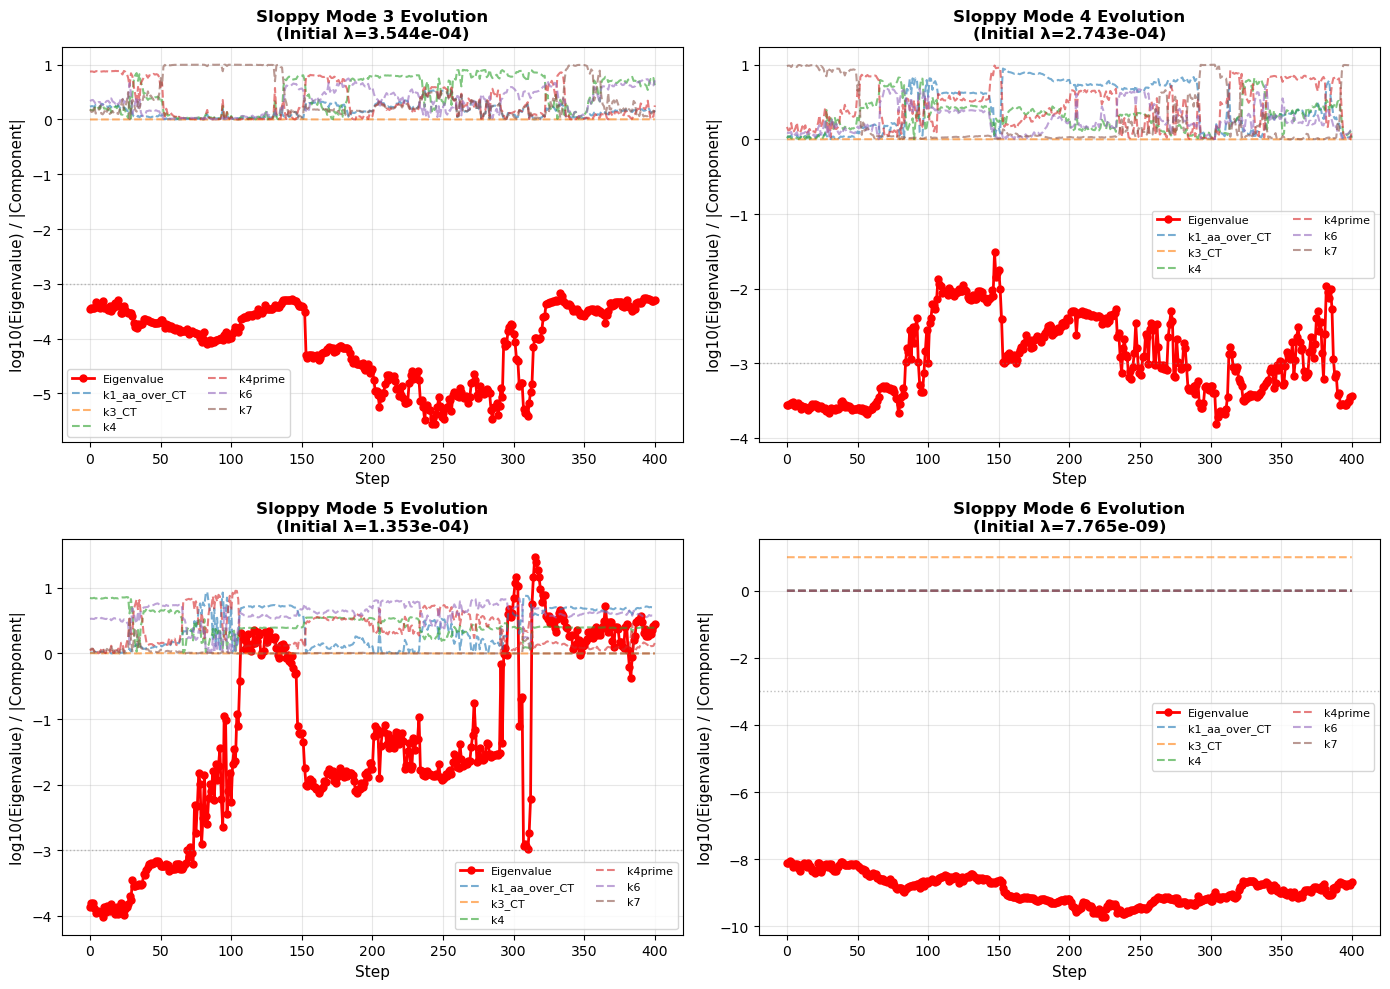


SLOPPY MODE EVOLUTION SUMMARY

Mode 3:
  Initial eigenvalue: 3.544e-04
  Final eigenvalue:   4.997e-04
  Ratio (final/init): 1.410
  Min match quality:   0.6085
  Mean match quality:  0.9741

Mode 4:
  Initial eigenvalue: 2.743e-04
  Final eigenvalue:   3.678e-04
  Ratio (final/init): 1.341
  Min match quality:   0.6324
  Mean match quality:  0.9657

Mode 5:
  Initial eigenvalue: 1.353e-04
  Final eigenvalue:   2.788e+00
  Ratio (final/init): 20606.302
  Min match quality:   0.5539
  Mean match quality:  0.9764

Mode 6:
  Initial eigenvalue: 7.765e-09
  Final eigenvalue:   2.141e-09
  Ratio (final/init): 0.276
  Min match quality:   1.0000
  Mean match quality:  1.0000


In [45]:
# === Visualization: Evolution of Sloppy Eigenmodes ===

# Identify sloppy modes (eigenvalues < sloppy_threshold)
eigvals_array = np.array(eigvals_history)
sloppy_mask = eigvals_array < sloppy_threshold

# Find which modes are sloppy at the initial step
initial_sloppy = np.where(sloppy_mask[0])[0]
n_sloppy = len(initial_sloppy)

if n_sloppy > 0:
    print(f"Found {n_sloppy} sloppy mode(s) at initial step: {initial_sloppy}")
    
    # Create subplots for each sloppy mode
    n_cols = min(2, n_sloppy)
    n_rows = int(np.ceil(n_sloppy / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    if n_sloppy == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    steps = np.arange(len(eigvals_history))
    
    for plot_idx, mode_idx in enumerate(initial_sloppy):
        ax = axes[plot_idx]
        
        # Plot eigenvalue evolution
        mask = eigvals_array[:, mode_idx] > 0
        if np.any(mask):
            ax.plot(steps[mask], np.log10(eigvals_array[mask, mode_idx]), 
                   'o-', color='red', markersize=5, linewidth=2, label='Eigenvalue')
        
        # Plot eigenvector component magnitudes
        eigvecs_array = np.array(eigvecs_history)  # (n_steps+1) x P x P
        abs_components = np.abs(eigvecs_array[:, :, mode_idx])  # (n_steps+1) x P
        
        for param_idx in range(P):
            ax.plot(steps, abs_components[:, param_idx], '--', alpha=0.6, 
                   label=f'{param_names[param_idx]}', linewidth=1.5)
        
        ax.axhline(np.log10(sloppy_threshold), color='gray', linestyle=':', linewidth=1, alpha=0.5)
        ax.set_xlabel('Step', fontsize=11)
        ax.set_ylabel('log10(Eigenvalue) / |Component|', fontsize=11)
        ax.set_title(f'Sloppy Mode {mode_idx+1} Evolution\n(Initial λ={eigvals_array[0, mode_idx]:.3e})', 
                    fontsize=12, fontweight='bold')
        ax.legend(ncol=2, fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_sloppy, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SLOPPY MODE EVOLUTION SUMMARY")
    print("="*60)
    for mode_idx in initial_sloppy:
        initial_eigval = eigvals_array[0, mode_idx]
        final_eigval = eigvals_array[-1, mode_idx]
        ratio = final_eigval / initial_eigval if initial_eigval > 0 else np.nan
        print(f"\nMode {mode_idx+1}:")
        print(f"  Initial eigenvalue: {initial_eigval:.3e}")
        print(f"  Final eigenvalue:   {final_eigval:.3e}")
        print(f"  Ratio (final/init): {ratio:.3f}")
        
        # Check match quality over time
        match_qual = [m[mode_idx] if m is not None else 1.0 for m in match_quality_history]
        min_match = np.min(match_qual[1:])  # Skip first (None)
        mean_match = np.mean(match_qual[1:])
        print(f"  Min match quality:   {min_match:.4f}")
        print(f"  Mean match quality:  {mean_match:.4f}")
else:
    print("No sloppy modes found at initial step (all eigenvalues >= threshold)")


SLOPPY SUBSPACE TRACKING

Sloppy subspace dimensions at each step:
  Step 0: 4 sloppy mode(s)
  Step 20: 4 sloppy mode(s)
  Step 40: 4 sloppy mode(s)
  Step 60: 4 sloppy mode(s)
  Step 80: 3 sloppy mode(s)
  Step 100: 3 sloppy mode(s)
  Step 120: 4 sloppy mode(s)
  Step 140: 4 sloppy mode(s)
  Step 160: 4 sloppy mode(s)
  Step 180: 4 sloppy mode(s)
  Step 200: 4 sloppy mode(s)
  Step 220: 4 sloppy mode(s)
  Step 240: 4 sloppy mode(s)
  Step 260: 5 sloppy mode(s)
  Step 280: 5 sloppy mode(s)
  Step 300: 3 sloppy mode(s)
  Step 320: 4 sloppy mode(s)
  Step 340: 4 sloppy mode(s)
  Step 360: 3 sloppy mode(s)
  Step 380: 4 sloppy mode(s)
  Step 400: 4 sloppy mode(s)


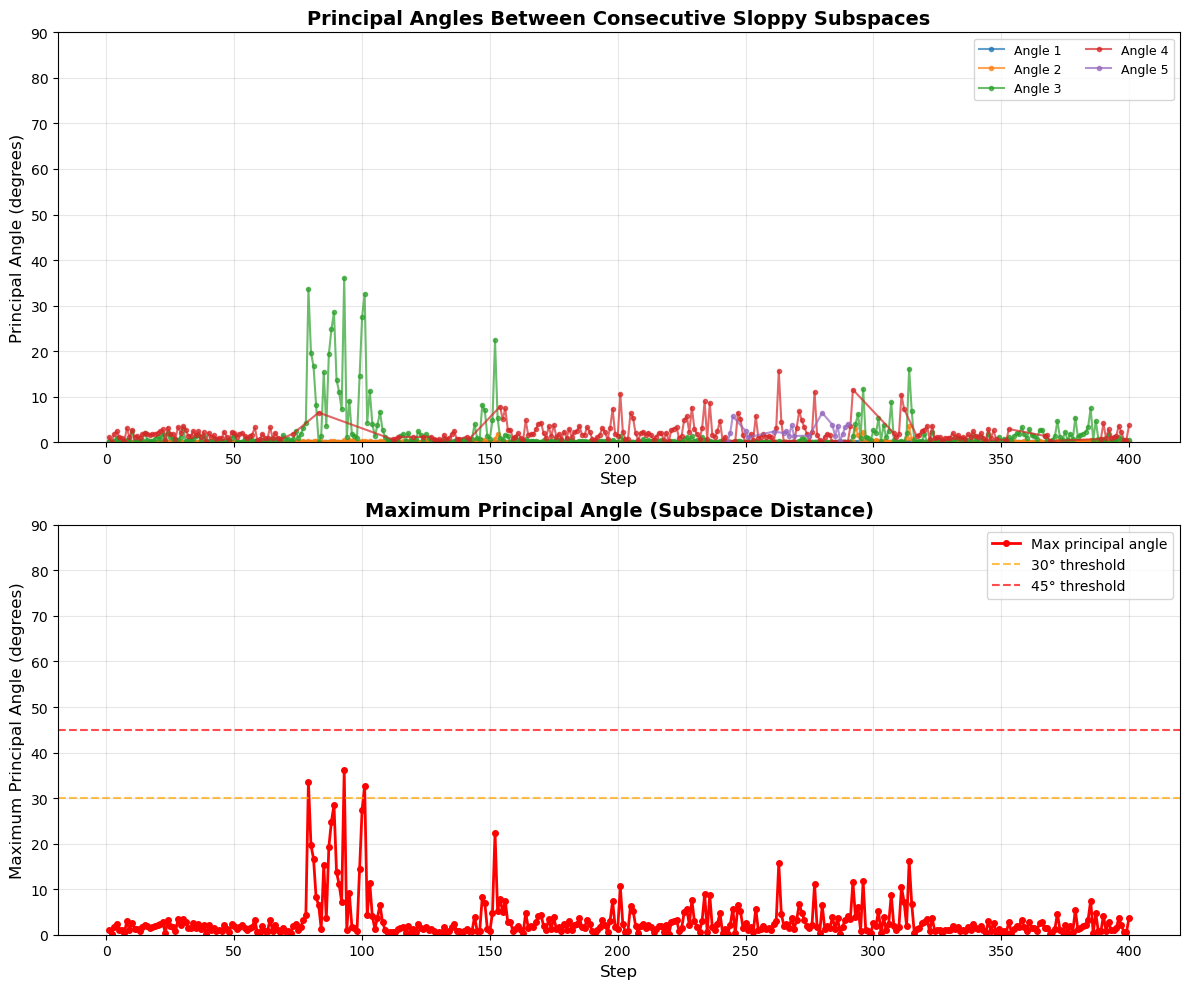


PRINCIPAL ANGLE STATISTICS
Mean maximum principal angle: 3.06°
Max maximum principal angle:  36.07°
Steps with max angle > 30°:   3
Steps with max angle > 45°:   0

⚠️  WARNING: Sloppy subspace dimension changed at 62 step(s)
   This indicates modes crossing the sloppy threshold

INTERPRETATION:
Principal angles measure the 'distance' between subspaces:
  • 0° = identical subspaces
  • < 30° = very similar subspaces (robust)
  • 30-45° = moderately different
  • > 45° = substantially different subspaces

If principal angles remain small, the sloppy subspace is robust
even if individual eigenvectors change significantly.


In [46]:
# === Sloppy Subspace Tracking via Principal Angles ===

def compute_principal_angles(U1, U2):
    """
    Compute principal angles between two subspaces.
    
    Args:
        U1, U2: Matrices whose columns span the two subspaces (P x k1) and (P x k2)
    
    Returns:
        angles: Principal angles in radians (min(k1, k2) angles)
    """
    # Orthonormalize the input matrices
    Q1, _ = np.linalg.qr(U1)
    Q2, _ = np.linalg.qr(U2)
    
    # Compute SVD of Q1^T @ Q2
    M = Q1.T @ Q2
    _, s, _ = np.linalg.svd(M, full_matrices=False)
    
    # Clamp singular values to [0, 1] to avoid numerical issues
    s = np.clip(s, 0, 1)
    
    # Principal angles are arccos of singular values
    angles = np.arccos(s)
    
    return angles

# Extract sloppy subspaces at each step
sloppy_subspaces = []
sloppy_dimensions = []
principal_angles_history = []

print("="*60)
print("SLOPPY SUBSPACE TRACKING")
print("="*60)

for step_idx in range(len(eigvals_history)):
    eigvals = eigvals_history[step_idx]
    eigvecs = eigvecs_history[step_idx]
    
    # Find sloppy eigenvectors (eigenvalues < sloppy_threshold)
    sloppy_mask = eigvals < sloppy_threshold
    sloppy_indices = np.where(sloppy_mask)[0]
    
    if len(sloppy_indices) > 0:
        # Extract sloppy subspace (columns are eigenvectors)
        sloppy_subspace = eigvecs[:, sloppy_indices]
        sloppy_subspaces.append(sloppy_subspace)
        sloppy_dimensions.append(len(sloppy_indices))
    else:
        # No sloppy modes - use empty subspace
        sloppy_subspaces.append(np.zeros((P, 0)))
        sloppy_dimensions.append(0)
    
    # Compute principal angles with previous step (if available)
    if step_idx > 0:
        prev_subspace = sloppy_subspaces[step_idx - 1]
        curr_subspace = sloppy_subspaces[step_idx]
        
        if prev_subspace.shape[1] > 0 and curr_subspace.shape[1] > 0:
            angles = compute_principal_angles(prev_subspace, curr_subspace)
            principal_angles_history.append(angles)
        else:
            # One or both subspaces are empty
            principal_angles_history.append(np.array([]))

print(f"\nSloppy subspace dimensions at each step:")
for step_idx, dim in enumerate(sloppy_dimensions):
    if step_idx % 20 == 0 or step_idx == len(sloppy_dimensions) - 1:
        print(f"  Step {step_idx}: {dim} sloppy mode(s)")

# === Visualization: Principal Angles ===

# Filter out empty angle arrays
valid_angles = [(i+1, angles) for i, angles in enumerate(principal_angles_history) if len(angles) > 0]
steps_with_angles = [s for s, _ in valid_angles]
angles_arrays = [a for _, a in valid_angles]

if len(angles_arrays) > 0:
    # Find maximum number of angles (dimension of smallest subspace)
    max_angles = max(len(a) for a in angles_arrays)
    
    # Create array for plotting (pad with NaN if dimensions differ)
    angles_matrix = np.full((len(angles_arrays), max_angles), np.nan)
    for i, angles in enumerate(angles_arrays):
        angles_matrix[i, :len(angles)] = angles
    
    # Convert to degrees for easier interpretation
    angles_matrix_deg = np.degrees(angles_matrix)
    
    # Plot principal angles
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: All principal angles
    ax1 = axes[0]
    for angle_idx in range(max_angles):
        mask = ~np.isnan(angles_matrix_deg[:, angle_idx])
        if np.any(mask):
            ax1.plot(np.array(steps_with_angles)[mask], angles_matrix_deg[mask, angle_idx], 
                    'o-', label=f'Angle {angle_idx+1}', markersize=3, linewidth=1.5, alpha=0.7)
    
    ax1.set_xlabel('Step', fontsize=12)
    ax1.set_ylabel('Principal Angle (degrees)', fontsize=12)
    ax1.set_title('Principal Angles Between Consecutive Sloppy Subspaces', fontsize=14, fontweight='bold')
    ax1.legend(ncol=2, fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 90])
    
    # Plot 2: Maximum principal angle (subspace distance metric)
    ax2 = axes[1]
    max_angles_per_step = [np.max(a) if len(a) > 0 else np.nan for a in angles_arrays]
    max_angles_deg = np.degrees(max_angles_per_step)
    
    ax2.plot(steps_with_angles, max_angles_deg, 'o-', color='red', markersize=4, linewidth=2, label='Max principal angle')
    ax2.axhline(30, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='30° threshold')
    ax2.axhline(45, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='45° threshold')
    
    ax2.set_xlabel('Step', fontsize=12)
    ax2.set_ylabel('Maximum Principal Angle (degrees)', fontsize=12)
    ax2.set_title('Maximum Principal Angle (Subspace Distance)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 90])
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*60)
    print("PRINCIPAL ANGLE STATISTICS")
    print("="*60)
    print(f"Mean maximum principal angle: {np.nanmean(max_angles_deg):.2f}°")
    print(f"Max maximum principal angle:  {np.nanmax(max_angles_deg):.2f}°")
    print(f"Steps with max angle > 30°:   {np.sum(max_angles_deg > 30)}")
    print(f"Steps with max angle > 45°:   {np.sum(max_angles_deg > 45)}")
    
    # Check if subspace dimension changes
    dim_changes = [sloppy_dimensions[i] != sloppy_dimensions[i-1] 
                   for i in range(1, len(sloppy_dimensions))]
    if np.any(dim_changes):
        print(f"\n⚠️  WARNING: Sloppy subspace dimension changed at {np.sum(dim_changes)} step(s)")
        print("   This indicates modes crossing the sloppy threshold")
    else:
        print(f"\n✓ Sloppy subspace dimension remained constant: {sloppy_dimensions[0]} mode(s)")
    
    print("\n" + "="*60)
    print("INTERPRETATION:")
    print("="*60)
    print("Principal angles measure the 'distance' between subspaces:")
    print("  • 0° = identical subspaces")
    print("  • < 30° = very similar subspaces (robust)")
    print("  • 30-45° = moderately different")
    print("  • > 45° = substantially different subspaces")
    print("\nIf principal angles remain small, the sloppy subspace is robust")
    print("even if individual eigenvectors change significantly.")
else:
    print("No valid principal angles to plot (subspaces may be empty)")


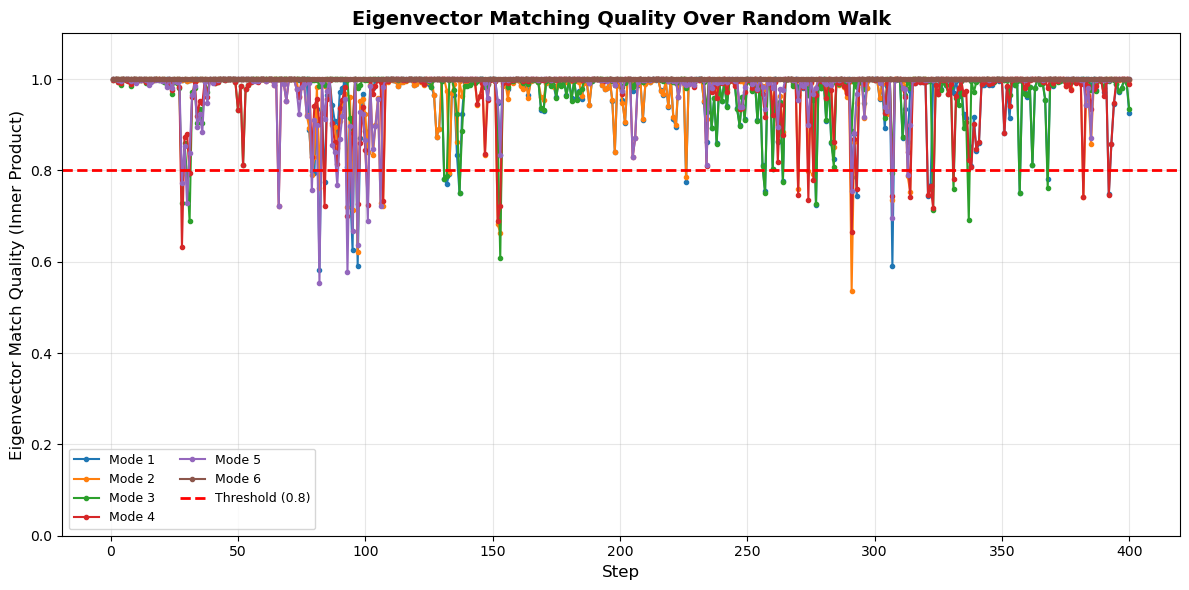

Eigenvector Matching Quality Statistics:
  Minimum across all steps: 0.5356
  Mean across all steps:    0.9752
  Steps below threshold:    96


In [47]:
# === Visualization: Eigenvector Matching Quality ===

# Filter out None values (first step)
match_qual_array = np.array([m for m in match_quality_history if m is not None])
steps_match = np.arange(1, len(match_quality_history))  # Start from step 1

fig, ax = plt.subplots(figsize=(12, 6))

# Plot matching quality for each eigenvector
for i in range(P):
    ax.plot(steps_match, match_qual_array[:, i], 'o-', label=f'Mode {i+1}', markersize=3, linewidth=1.5)

ax.axhline(eigenvector_match_threshold, color='red', linestyle='--', linewidth=2, 
          label=f'Threshold ({eigenvector_match_threshold})')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Eigenvector Match Quality (Inner Product)', fontsize=12)
ax.set_title('Eigenvector Matching Quality Over Random Walk', fontsize=14, fontweight='bold')
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Print statistics
print("Eigenvector Matching Quality Statistics:")
print(f"  Minimum across all steps: {match_qual_array.min():.4f}")
print(f"  Mean across all steps:    {match_qual_array.mean():.4f}")
print(f"  Steps below threshold:    {np.sum(match_qual_array < eigenvector_match_threshold)}")
